Question No : 1

In [1]:
import pandas as pd

In [2]:
data = {'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
        'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]}


In [3]:
df=pd.DataFrame(data)

In [4]:
df

,Customer_ID,Purchase_Amount
0,101,200
1,102,150
2,103,180
3,101,220
4,104,300
5,102,200
6,101,100
7,105,400
8,102,250
9,103,300


In [5]:
#1.	Group customers by their IDs.
#2. Calculate the total number of purchases per customer.
total_purchase=df.groupby('Customer_ID',as_index=False)['Purchase_Amount'].sum()
print("Total Purchases per customer:")
print(total_purchase)

Total Purchases per customer:
   Customer_ID  Purchase_Amount
0          101              520
1          102              600
2          103              480
3          104              300
4          105              400


In [6]:
#3.	Identify the top 3 frequent customers.
top_3_customers=total_purchase.sort_values(by='Purchase_Amount',ascending=False).head(3)
print("\nTop 3 Frequent customers:")
print(top_3_customers)



Top 3 Frequent customers:
   Customer_ID  Purchase_Amount
1          102              600
0          101              520
2          103              480


Question No : 2

In [7]:
import pandas as pd
import numpy as np

In [8]:
data = {'Day': range(1, 31),
        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,
                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,
                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}


In [9]:
df=pd.DataFrame(data)

In [10]:
#1.Calculate the Q1 (25th percentile) and Q3 (75th percentile).
Q1=df['Sales'].quantile(0.25)
Q3=df['Sales'].quantile(0.75)
print(f"Q1: {Q1}, Q3: {Q3}")

Q1: 31.5, Q3: 83.75


In [11]:
#2. Determine the IQR.
IQR=Q3-Q1
print("IQR:",IQR)

IQR: 52.25


In [12]:
#3. Identify the Lower Bound and Upper Bound.
lower_bound=Q1-1.5 * IQR
upper_bound=Q3+1.5 * IQR
print("Lower Bound:",lower_bound,"Upper Bound",upper_bound)

Lower Bound: -46.875 Upper Bound 162.125


In [13]:
#4.Detect and display the outliers.
outliers=df[(df['Sales']<lower_bound) | (df['Sales']>upper_bound)]
print("Outliers Detected:",outliers)

Outliers Detected:     Day  Sales
29   30    200


In [14]:
#5.Replace the Outliers with the Median Value.
median_value=df['Sales'].median()
df['Sales']=np.where((df['Sales']<lower_bound) | (df['Sales']>upper_bound),median_value,df['Sales'])      
print("Data after Replacing Outliers with median:",df)

Data after Replacing Outliers with median:     Day  Sales
0     1   25.0
1     2   30.0
2     3   28.0
3     4   45.0
4     5   55.0
5     6   60.0
6     7   22.0
7     8   80.0
8     9   95.0
9    10  120.0
10   11   33.0
11   12   29.0
12   13   27.0
13   14   35.0
14   15   40.0
15   16   50.0
16   17   85.0
17   18  110.0
18   19  105.0
19   20   92.0
20   21   30.0
21   22   34.0
22   23   31.0
23   24   33.0
24   25   36.0
25   26   42.0
26   27   44.0
27   28   48.0
28   29   90.0
29   30   43.0


Question No:3

In [15]:
import pandas as pd
from scipy.stats import ttest_ind


In [16]:
data = {'Group': ['Treatment']*10 + ['Control']*10,
        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}


In [17]:
df=pd.DataFrame(data)

In [18]:
df

,Group,Blood_Pressure
0,Treatment,120
1,Treatment,115
2,Treatment,118
3,Treatment,123
4,Treatment,122
5,Treatment,119
6,Treatment,124
7,Treatment,117
8,Treatment,116
9,Treatment,121


In [20]:
#1.	Perform an Independent T-Test.

treatment = df[df['Group'] == 'Treatment']['Blood_Pressure']  
control = df[df['Group'] == 'Control']['Blood_Pressure']      

print("\nTreatment Group Blood Pressure:")
print(treatment)
print("\nControl Group Blood Pressure:")
print(control)


Treatment Group Blood Pressure:
0    120
1    115
2    118
3    123
4    122
5    119
6    124
7    117
8    116
9    121
Name: Blood_Pressure, dtype: int64

Control Group Blood Pressure:
10    130
11    135
12    140
13    138
14    142
15    136
16    139
17    134
18    137
19    141
Name: Blood_Pressure, dtype: int64


In [25]:
t_stat, p_value = ttest_ind(treatment, control)


In [26]:
#2.	State the null and alternative hypotheses.
#Null Hypothesis(H0): There is no significant difference in blood pressure between the two groups.
#Alternative Hypothesis(H1): There is a significant difference in blood pressure between the two groups.

In [27]:
#3.	Calculate the p-value
print("\nT-Statistic:", t_stat)
print("P-Value:", p_value)



T-Statistic: -11.870553692962726
P-Value: 6.008066605173374e-10


In [28]:
#4.	Conclude whether the drug has a significant effect.
if p_value < 0.05:
    print("Reject the Null Hypothesis: The drug has a significant effect.")
else:
    print("Fail to Reject the Null Hypothesis: The drug does not have a significant effect.")

Reject the Null Hypothesis: The drug has a significant effect.


Question No:4

In [29]:
import pandas as pd

In [33]:
# Data (example)
tv_ads = np.array([100, 200, 300, 400, 500])
social_media_ads = np.array([80, 180, 280, 380, 480])
sales = np.array([20, 40, 60, 80, 100])

In [34]:


# 1. Covariance Calculation
cov_tv_sales = np.cov(tv_ads, sales, ddof=0)[0, 1]  # ddof=0 for population covariance
cov_social_sales = np.cov(social_media_ads, sales, ddof=0)[0, 1]

print("Covariance (TV vs Sales):", cov_tv_sales)
print("Covariance (Social Media vs Sales):", cov_social_sales)

# 2. Correlation Calculation
corr_tv_sales = np.corrcoef(tv_ads, sales)[0, 1]
corr_social_sales = np.corrcoef(social_media_ads, sales)[0, 1]

print("Correlation (TV vs Sales):", corr_tv_sales)
print("Correlation (Social Media vs Sales):", corr_social_sales)

# 3. Determine which ad is more effective
if corr_tv_sales > corr_social_sales:
    print("TV Ads have a stronger impact on Sales.")
else:
    print("Social Media Ads have a stronger impact on Sales.")

Covariance (TV vs Sales): 4000.0
Covariance (Social Media vs Sales): 4000.0
Correlation (TV vs Sales): 0.9999999999999999
Correlation (Social Media vs Sales): 0.9999999999999999
Social Media Ads have a stronger impact on Sales.


Question No:5

Mean Delivery Time: 65.0625
Standard Deviation of Delivery Time: 41.718504212759115


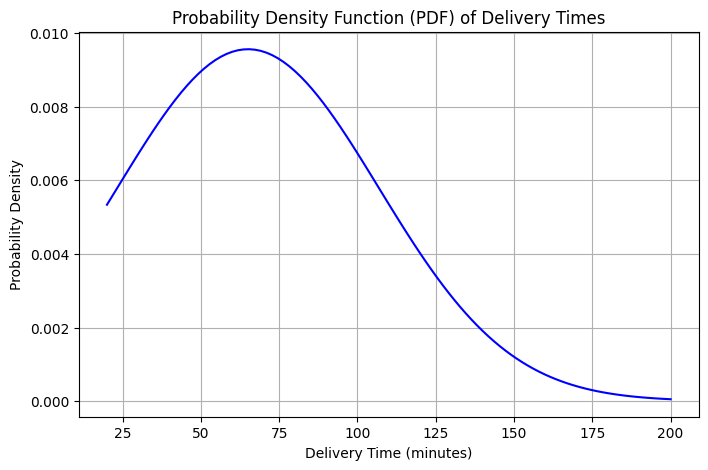

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Dataset (make sure the variable name is exactly this)
delivery_times = np.array([25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 
                           33, 29, 27, 35, 40, 50, 85, 110, 105, 92, 
                           30, 34, 31, 33, 36, 42, 44, 48, 90, 200, 
                           20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 
                           80, 84, 90, 110, 123, 145, 150, 160])

# 1. Mean
mean_delivery = np.mean(delivery_times)

# 2. Standard Deviation
std_delivery = np.std(delivery_times)

print("Mean Delivery Time:", mean_delivery)
print("Standard Deviation of Delivery Time:", std_delivery)

# 3. Plot PDF
x = np.linspace(min(delivery_times), max(delivery_times), 100)
pdf = norm.pdf(x, mean_delivery, std_delivery)

plt.figure(figsize=(8,5))
plt.plot(x, pdf, color='blue')
plt.title("Probability Density Function (PDF) of Delivery Times")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.show()